# Jesus Mario Caro Quintana - Ciencia de datos - Grupo 12pm a 1pm

# cargar el csv que anteriormente era un txt

- Nota: puse capturas de las impresiones de cada una de las celdas por si no puede ejecutar las celdas por tema de version de pandas o algo asi

In [ ]:
import pandas as pd

df = pd.read_csv("25001_GVE01_14052025.csv") # con read_csv asigno la ruta del archivo a un objeto para poder manejarlo
df.head() # muestro la cabeza del csv

,fecha,precip,evap,tmax,tmin
0,01/01/1961,0,Nulo,25,13
1,02/01/1961,0,Nulo,27.5,14
2,03/01/1961,0,Nulo,31,11
3,04/01/1961,0,Nulo,32,13
4,05/01/1961,0,Nulo,29,14


- Explicacion.

Aqui todos los datos del csv son del tipo string, no estan limpios aun

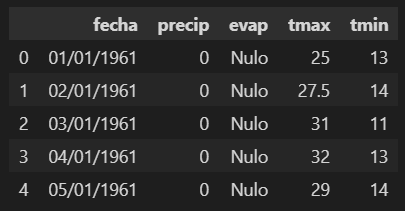

# en esta funcion es donde se hace la limpieza de datos
asigno el tipo del que va a ser cada columna del dataframe

In [135]:
def limpieza(df):
    df.replace("Nulo", pd.NA, inplace=True) # todos las celdas con el string "Nulo", los transforma en NaN(osea datos nulos)

    df["precip"] = pd.to_numeric(df["precip"]) # las celdas de la columna precip van a ser numerico
    df["evap"] = pd.to_numeric(df["evap"]) # las celdas de la columna evap van a ser numerico
    df["tmax"] = pd.to_numeric(df["tmax"]) # las celdas de la columna tmax van a ser numerico
    df["tmin"] = pd.to_numeric(df["tmin"]) # las celdas de la columna tmin van a ser numerico

    df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True) # las celdas de la columna fecha van a ser datetime
    return df

In [136]:
# esto es para mostrar los datos ya transformados a sus respectivos tipos
df=limpieza(df)
df.head()

,fecha,precip,evap,tmax,tmin
0,1961-01-01,0.0,NaN,25.0,13.0
1,1961-01-02,0.0,NaN,27.5,14.0
2,1961-01-03,0.0,NaN,31.0,11.0
3,1961-01-04,0.0,NaN,32.0,13.0
4,1961-01-05,0.0,NaN,29.0,14.0


- Explicacion.

aqui podemos ver la tabla con los tipos ya asignado a cada columna

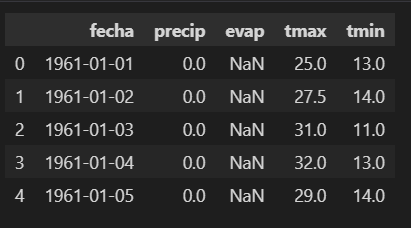

# Verificar que cada columna ya es del tipo que le corresponde

In [138]:
df.dtypes

fecha     datetime64[us]
precip           float64
evap             float64
tmax             float64
tmin             float64
dtype: object

- Explicacion.

podemos ver el tipo de cada columna y nos damos cuenta que si se asigno correctamente el tipo a cada columna

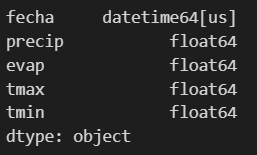

# La siguiente funcion es para verificar cuantos nulos hay en cada columna
-Esta funcion me sirve para validar que funciona correctamente la funcion de sustituir los nulos con la media de la columna.

-Creo 5 objetos que cuando el isnull() sea true va sumando y asi cuenta la cantidad de nulos que hay por columna.

In [ ]:
def verificar_si_hay_nulo(df):
    
    sumnulo0 = df["fecha"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna fecha
    sumnulo1 = df["precip"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna precip
    sumnulo2 = df["evap"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna evap
    sumnulo3 = df["tmax"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna tmax
    sumnulo4 = df["tmin"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna tmin

    # retorno un print para mostrar el numero de nulos de cada columna
    return print(f"Nulos de fecha: {sumnulo0}, Nulos de precip: {sumnulo1}, Nulos de evap: {sumnulo2}, Nulos de tmax: {sumnulo3}, Nulos de tmin: {sumnulo4}")

In [141]:
verificar_si_hay_nulo(df)

Nulos de fecha: 0, Nulos de precip: 40, Nulos de evap: 272, Nulos de tmax: 5, Nulos de tmin: 6


- Explicacion.

podemos ver la cantidad de nulos que hay en cada columna y nos damos cuenta de que la columna de las fechas no exiten datos nulos

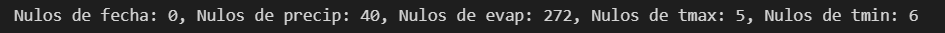

# La siguiente funcion es para contar cuantos nulos hay por fecha

In [148]:
def nulos_por_fecha(df):
    grupoFecha = df.groupby("fecha") # crea los grupos por fecha
    cont=0 # contador para ver cuantas iteraciones hace el ciclo para ver cuantos grupos se forman

    # fecha contiene las fechas, grupo contiene las filas de esa fecha, y el ciclo funciona mientras esten dentro de grupoFecha
    for fecha, grupo in grupoFecha:
        # creo un objeto el cual si isnull() es true cuenta nulos por columna y todo esto lo suma asi sacando el total de nulos por grupo
        totalnulos = grupo.isnull().sum().sum()
        cont+=1 # aqui esta el contador
        print(f"Total de nulos de la fecha {fecha}: {totalnulos}") # imprimo la fecha con el total de nulos por fecha
    print(f"Numero de grupos: {cont}")# imprimo el contador

In [149]:
nulos_por_fecha(df)

Total de nulos de la fecha 1961-01-01 00:00:00: 1
Total de nulos de la fecha 1961-01-02 00:00:00: 1
Total de nulos de la fecha 1961-01-03 00:00:00: 1
Total de nulos de la fecha 1961-01-04 00:00:00: 1
Total de nulos de la fecha 1961-01-05 00:00:00: 1
Total de nulos de la fecha 1961-01-06 00:00:00: 1
Total de nulos de la fecha 1961-01-07 00:00:00: 1
Total de nulos de la fecha 1961-01-08 00:00:00: 1
Total de nulos de la fecha 1961-01-09 00:00:00: 1
Total de nulos de la fecha 1961-01-10 00:00:00: 1
Total de nulos de la fecha 1961-01-11 00:00:00: 1
Total de nulos de la fecha 1961-01-12 00:00:00: 1
Total de nulos de la fecha 1961-01-13 00:00:00: 1
Total de nulos de la fecha 1961-01-14 00:00:00: 1
Total de nulos de la fecha 1961-01-15 00:00:00: 1
Total de nulos de la fecha 1961-01-16 00:00:00: 1
Total de nulos de la fecha 1961-01-17 00:00:00: 1
Total de nulos de la fecha 1961-01-18 00:00:00: 1
Total de nulos de la fecha 1961-01-19 00:00:00: 1
Total de nulos de la fecha 1961-01-20 00:00:00: 1


- explicacion.



como podemos ver indica cuantos nulos hay por fecha, al final se ve el contador y lo utilizo para ver si hay fechas repetidas los cuales se forman grupos con el groupby, pero vemos que hay 19574 grupos, quiere decir que las fechas son unicas y no se repiten ya que hay 19574 filas en el dataframe

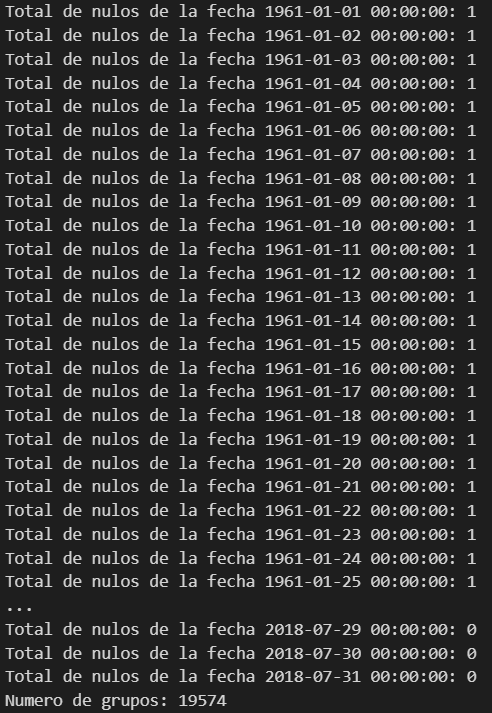


# funcion para calcular la media de cada columna y sustituir los nulos de cada columna con su respectiva media.

In [ ]:
def mediadenulos(df):
    
    columnas = ["precip","evap","tmax","tmin"] # creo una lista con el nombre de las columnas
    for columna in columnas: # recorro las columnas
        media = df[columna].mean() # saco la media de la columna que le toca en la iteracion
        df[columna] = df[columna].fillna(media, inplace=True)#a la columna de la iteracion con el fillna() sustituyo todos los valores nulos por la media
        print(f"media de {columna}: {media}") # imprimo la media de cada columna
    return df

In [153]:
df=mediadenulos(df)
df.head(20)

media de precip: 2.2174516228115078
media de evap: 4.8821572894000616
media de tmax: 34.46880780826818
media de tmin: 16.657420278004906


C:\Users\caroq\AppData\Local\Temp\ipykernel_6556\82265991.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[columna] = df[columna].fillna(media, inplace=True)#a la columna de la iteracion con el fillna() sustituyo todos los valores nulos por la media


,fecha,precip,evap,tmax,tmin
0,1961-01-01,0.0,4.882157,25.0,13.0
1,1961-01-02,0.0,4.882157,27.5,14.0
2,1961-01-03,0.0,4.882157,31.0,11.0
3,1961-01-04,0.0,4.882157,32.0,13.0
4,1961-01-05,0.0,4.882157,29.0,14.0
5,1961-01-06,0.0,4.882157,24.0,14.5
6,1961-01-07,0.0,4.882157,28.5,10.0
7,1961-01-08,0.0,4.882157,32.0,12.0
8,1961-01-09,0.0,4.882157,33.5,11.0
9,1961-01-10,0.0,4.882157,32.5,9.5


- Explicacion.

imprimo la media en cada iteracion para verificar que saca la media de cada columna correctamente, en la tabla ya podemos ver que los nulos se sustituyeron por la media

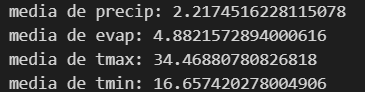

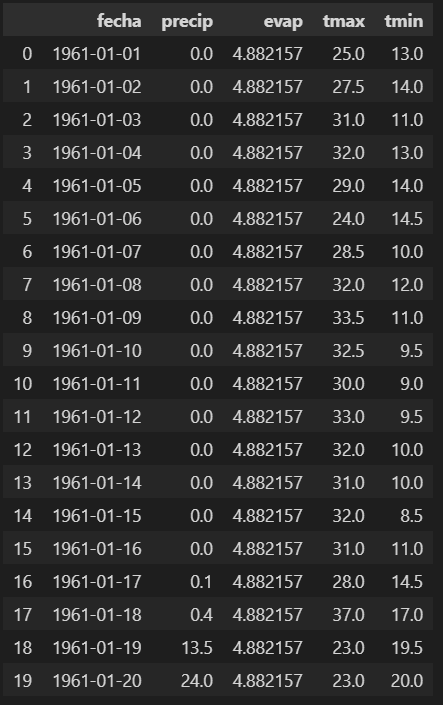

In [155]:
verificar_si_hay_nulo(df)

Nulos de fecha: 0, Nulos de precip: 0, Nulos de evap: 0, Nulos de tmax: 0, Nulos de tmin: 0


- Explicacion.

Aqui ya podemos ver que no hay ningun nulo en cada una de las columnas y que se sustituyo correctamente los nulos con la media